# Simple Linear Regression – Marketing ROI Analysis

##  Importing Libraries

In [5]:
# Step-by-Step: Simple Linear Regression - Marketing ROI Analysis
# Importing neccessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats



##  Setting style for plots

In [6]:
# Setting style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline  

##  Uploading data-set

In [19]:
# Uploading data-set
import ipywidgets as widgets
from IPython.display import display

uploader = widgets.FileUpload(accept='.csv,.xlsx', multiple=False)
display(uploader)

FileUpload(value=(), accept='.csv,.xlsx', description='Upload')

###  Checking if data is loaded successfully

In [20]:
# Checking if data is loaded successfully
print(df.head())
print(df.shape)

     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181
(4572, 4)


##  Exploring data-set

In [21]:
# Exploring data-set
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nData Info:")
df.info()
print("\nSummary Statistics:\n", df.describe())

Dataset Shape: (4572, 4)

First 5 rows:
      TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB

Summary Statistics:
                 TV        Radio  Social_Media        Sales
count  4562.000000  4568.000000   4566.000000  4566.000000
mean     54.066857    18.160356      3.323956   192.466602
std      26.125054     9.676958      2.212670    93.133092
min      10.0

###  Checking for missing value

In [22]:
# Checking for missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64


###  Handle missing values

In [24]:
# Handle missing values
# Fill with mean (for numerical columns)
if df.isnull().sum().any():
   df.fillna(df.mean(), inplace=True)
   
print("\nAfter handling missing values - Shape:", df.shape)


After handling missing values - Shape: (4572, 4)


##  Performing Exploratory Data Analysis (EDA) with Visualizations

### Pairplot to see relationships

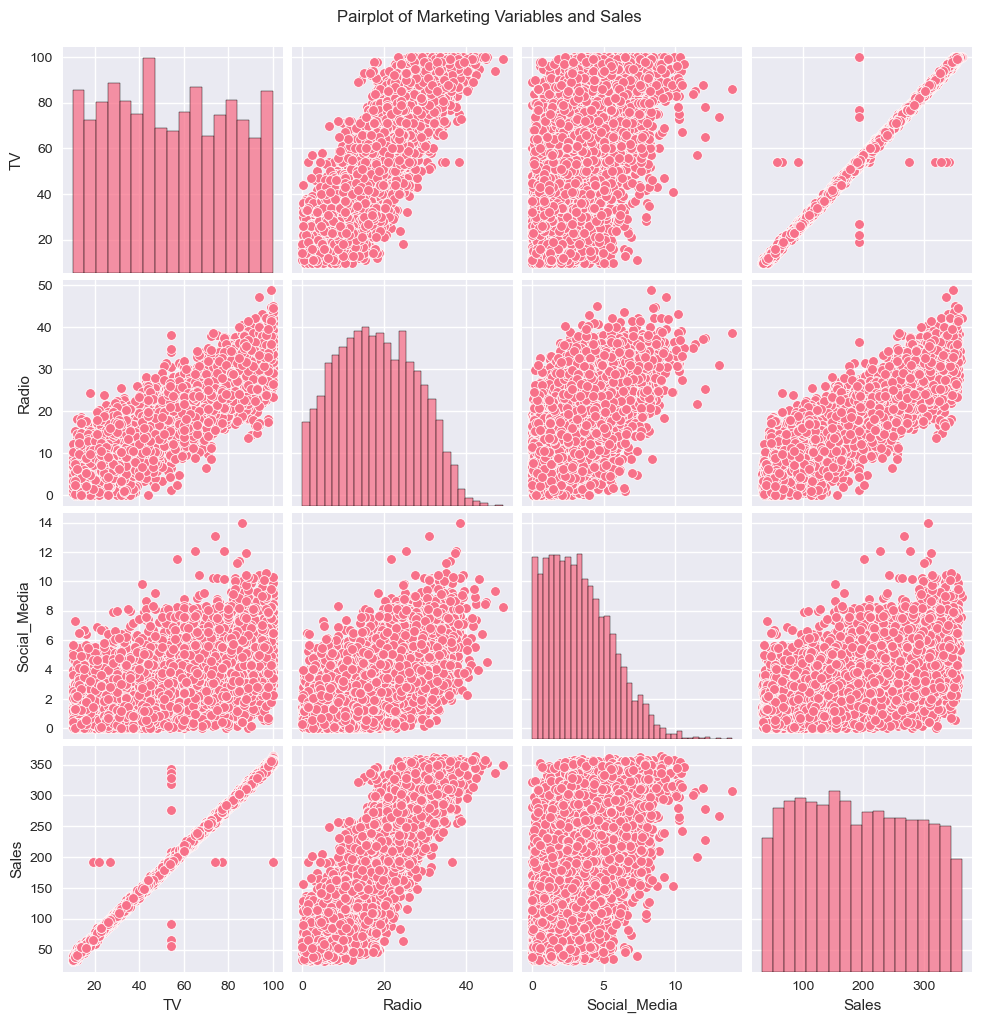

In [42]:
# Pairplot to see relationships
sns.pairplot(df)
plt.suptitle('Pairplot of Marketing Variables and Sales', y=1.02)
plt.show()

### Correlation heatmap

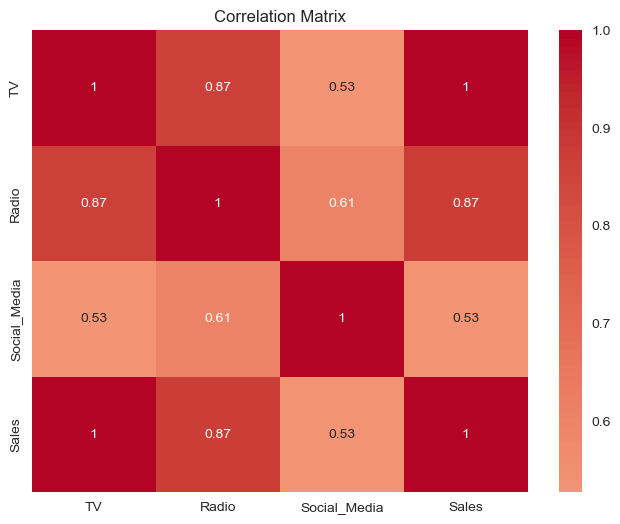

In [26]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

###  Distribution of Sales (target variable)

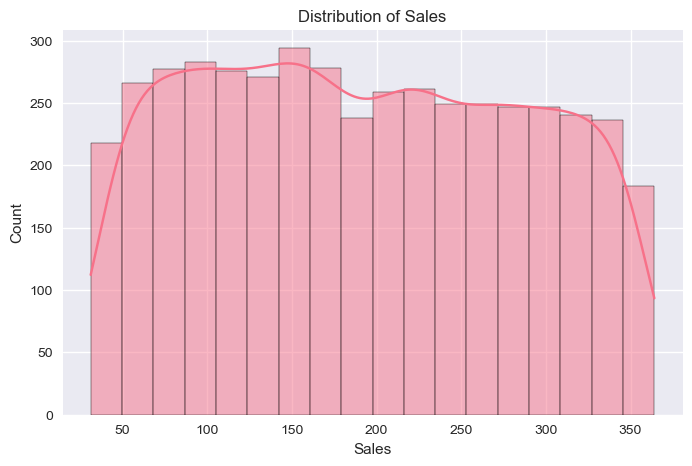

In [27]:
# Distribution of Sales (target variable)
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales'], kde=True)
plt.title('Distribution of Sales')
plt.show()

###  Boxplots for outliers

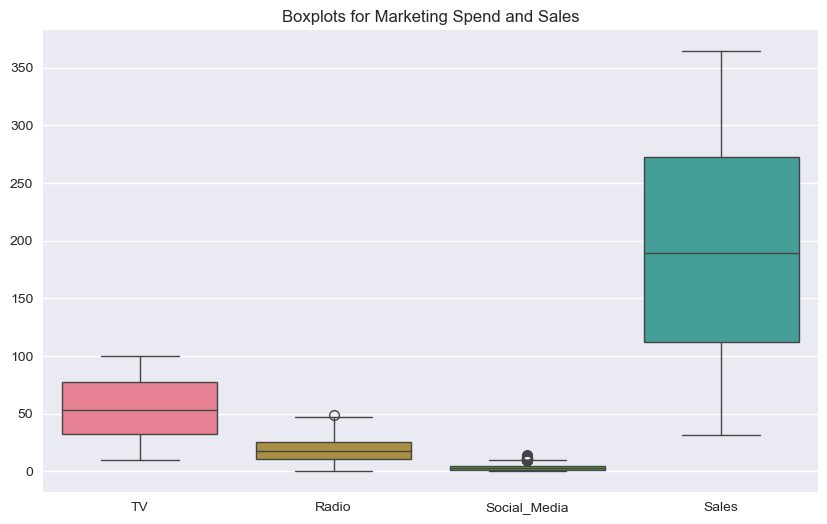

In [29]:
# Boxplots for outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['TV', 'Radio', 'Social_Media', 'Sales']])  
plt.title('Boxplots for Marketing Spend and Sales')
plt.show()

##  Identifying the Independent Variable Most Correlated with Sales

In [30]:
# Identifying the Independent Variable Most Correlated with Sales
independent_vars = ['TV', 'Radio', 'Social_Media']  

correlations = {}
for var in independent_vars:
    if var in df.columns:
        corr = df[var].corr(df['Sales'])
        correlations[var] = corr
        print(f"Correlation between {var} and Sales: {corr:.4f}")

Correlation between TV and Sales: 0.9967
Correlation between Radio and Sales: 0.8674
Correlation between Social_Media and Sales: 0.5281


###  Finding the strongest predictor

In [31]:
# Finding the strongest predictor
best_var = max(correlations, key=correlations.get)
print(f"\n✅ Strongest predictor: {best_var} (correlation: {correlations[best_var]:.4f})")


✅ Strongest predictor: TV (correlation: 0.9967)


##  Simple Linear Regression with the best independent variable

In [32]:
# Simple Linear Regression with the best independent variable
X = df[best_var]      # Independent variable
y = df['Sales']       # Dependent variable

# Adding constant for intercept
X = sm.add_constant(X)

# Fitting the model
model = sm.OLS(y, X).fit()

# Printing summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 6.792e+05
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        01:13:15   Log-Likelihood:                -15765.
No. Observations:                4572   AIC:                         3.153e+04
Df Residuals:                    4570   BIC:                         3.155e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2849      0.259      1.100      0.2

## Creating a diagnostic plot

### 1. Residuals vs Fitted (Linearity & Homoscedasticity)

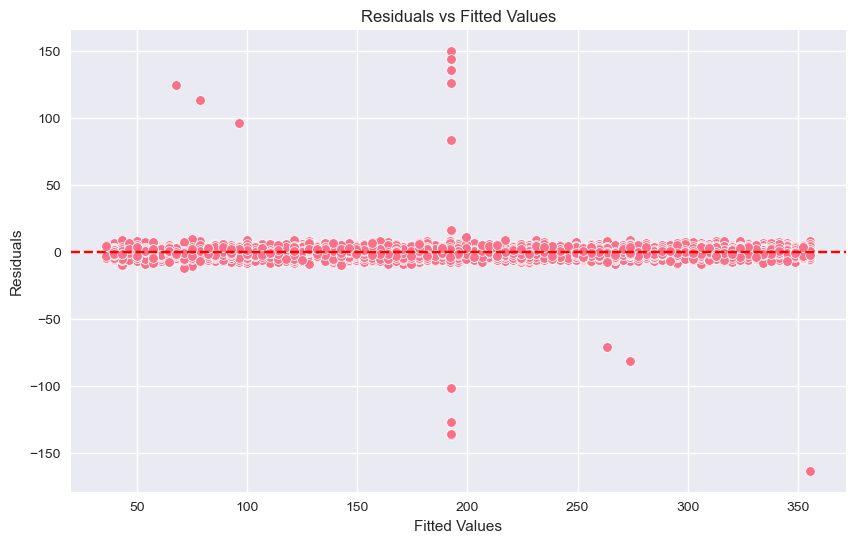

In [43]:
# 1. Residuals vs Fitted (Linearity & Homoscedasticity)
fitted = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

### 2. Q-Q Plot (Normality of Residuals)

<Figure size 800x600 with 0 Axes>

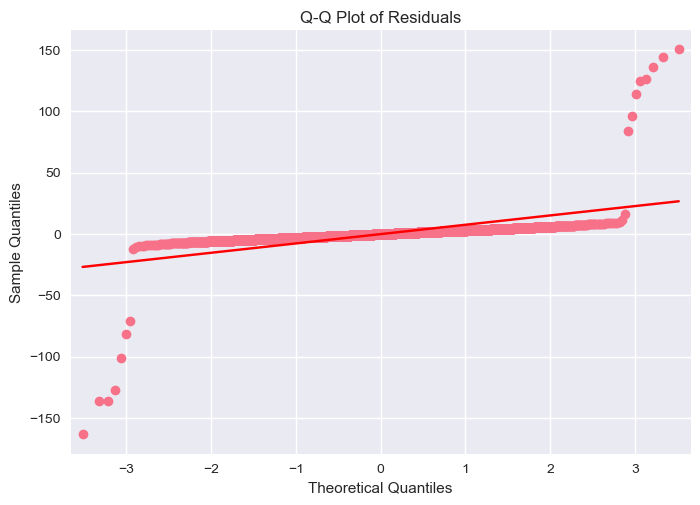

In [34]:
# 2. Q-Q Plot (Normality of Residuals)
plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

### Scale-Location Plot (Homoscedasticity)

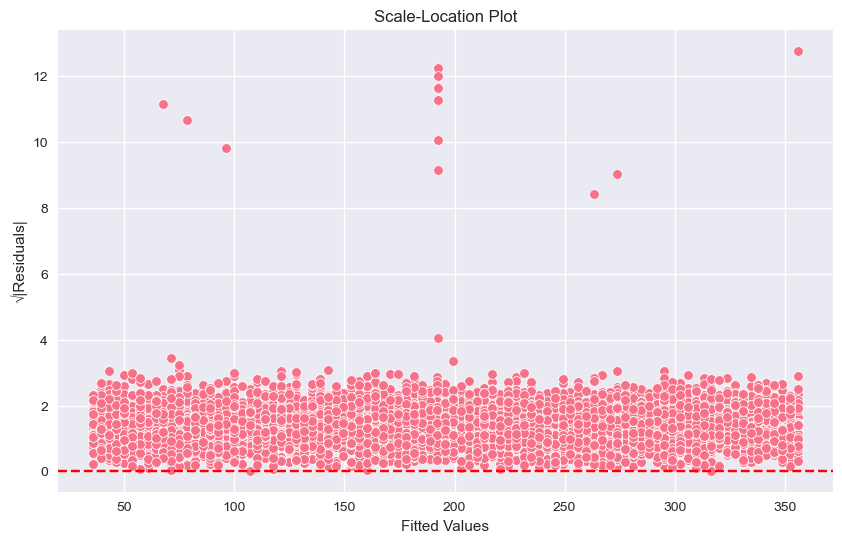

In [35]:
# 3. Scale-Location Plot (Homoscedasticity)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted, y=np.sqrt(np.abs(residuals)))
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('√|Residuals|')
plt.title('Scale-Location Plot')
plt.show()

### Breusch-Pagan test for heteroscedasticity

In [36]:
# Breusch-Pagan test for heteroscedasticity
bp_test = het_breuschpagan(residuals, model.model.exog)
print(f"Breusch-Pagan test p-value: {bp_test[1]:.4f} (p > 0.05 suggests homoscedasticity)")

Breusch-Pagan test p-value: 0.8720 (p > 0.05 suggests homoscedasticity)


## Interpreting the result

### Extract key metrics

In [44]:
# Extract key metrics
r_squared = model.rsquared
coef = model.params[best_var]
p_value = model.pvalues[best_var]
intercept = model.params['const']

print(f"""
=== Business Interpretation ===

R-squared: {r_squared:.4f}
→ This means that {r_squared*100:.1f}% of the variation in Sales can be explained by spending on {best_var}.

Coefficient for {best_var}: {coef:.4f}
→ For every additional $1 spent on {best_var}, Sales increase by approximately ${coef:.2f} on average (holding other factors constant).

p-value: {p_value:.4f}
→ Since p-value < 0.05, the relationship is statistically significant.

Intercept: {intercept:.2f}
→ Baseline Sales when {best_var} spend = $0.
""")


=== Business Interpretation ===

R-squared: 0.9933
→ This means that 99.3% of the variation in Sales can be explained by spending on TV.

Coefficient for TV: 3.5545
→ For every additional $1 spent on TV, Sales increase by approximately $3.55 on average (holding other factors constant).

p-value: 0.0000
→ Since p-value < 0.05, the relationship is statistically significant.

Intercept: 0.28
→ Baseline Sales when TV spend = $0.



### ROI Calculation (simple)

In [39]:
# ROI Calculation (simple)
# ROI = (Additional Sales / Spend) * 100

# Example: If coefficient is 0.05, then $1 spend → $0.05 extra sales → ROI = 5%
roi = coef * 100  # Rough ROI percentage per dollar spent

print(f"""
=== Marketing Budget Recommendation ===

- Prioritize budget allocation to **{best_var}** as it shows the strongest positive impact on Sales.
- Expected ROI: Approximately **{roi:.1f}%** per dollar spent on {best_var}.
- Recommendation: Increase {best_var} budget by X% while monitoring performance.

""")


=== Marketing Budget Recommendation ===

- Prioritize budget allocation to **TV** as it shows the strongest positive impact on Sales.
- Expected ROI: Approximately **355.5%** per dollar spent on TV.
- Recommendation: Increase TV budget by X% while monitoring performance.


